In [1]:
# 서포트 벡터 머신
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split

In [2]:
# 데이터 생성
iris = load_iris()

In [3]:
# 독립, 종속 분리(시각화를 위해 독립2개만 사용)
X = iris.data[:, 2:4]
y = iris.target

In [4]:
# 훈련, 테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
# 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# VM 모델 생성 및 학습 (선형 커널 사용)
# C값이 클수록 오차를 허용하지 않고, 작을수록 마진을 넓게 잡음
model = SVC(kernel='linear', C=1.0)
model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
# 성능평가
accuracy = model.score(X_test_scaled, y_test)
print(f"테스트 데이터 정확도: {accuracy:.2f}")

테스트 데이터 정확도: 0.97


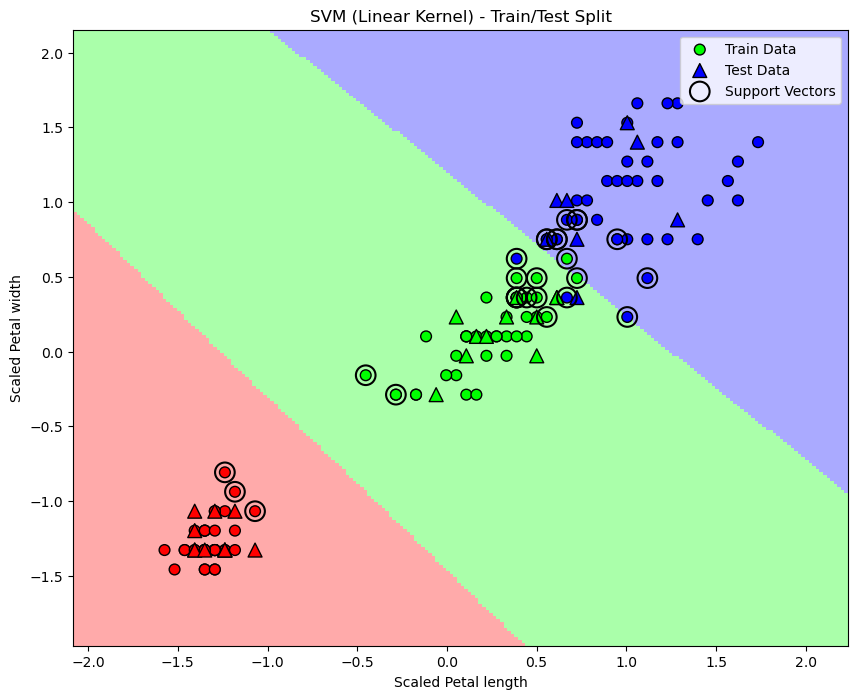

In [8]:
# 시각화
# 시각화 범위 설정 (스케일링 된 데이터 기준)
# -0.5, +0.5는 그래프 여백
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
hh = 0.02 # 바닥에 까는 크물망의 크기(점으로 색을 칠함)
xx, yy = np.meshgrid(np.arange(x_min, x_max, hh),
                     np.arange(y_min, y_max, hh))

# 그리드 데이터 예측 (스케일링 된 상태로 입력)
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# 훈련 데이터 (동그라미)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
            cmap=cmap_bold, edgecolor='k', s=60, label='Train Data')

# 테스트 데이터 (삼각형)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, 
            cmap=cmap_bold, marker='^', edgecolor='k', s=100, label='Test Data')

# [핵심] 서포트 벡터 표시 (경계선을 지탱하는 점들)
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], 
            s=200, facecolors='none', edgecolors='black', linewidths=1.5, label='Support Vectors')

plt.xlabel('Scaled Petal length')
plt.ylabel('Scaled Petal width')
plt.title('SVM (Linear Kernel) - Train/Test Split')
plt.legend()
plt.show()